# Set-up colab


In [1]:
#online for colab environment
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/USA
from fairness_metric_utils import *
from penalty_utils import *

/content/drive/MyDrive/USA


In [3]:
%cd /content/drive/MyDrive/USA/AdultCensus

/content/drive/MyDrive/USA/AdultCensus


# Load Data

In [ ]:
dataset_path = 'AdultCensus/adult-preprocessed.csv'
df=pd.read_csv(dataset_path)

fair_metrics=[ 'PPE', 'FPR', 'FPN', 'FPP'] #'GFA', 'PPA', 'FPR', 'PPE', 'FPA', 'OAE', 'EOP', 'FNP', 'FPP'
protected_attributes =['age', 'sex', 'race', 'edu']
mapping= {
    'age':{
        0: '11>a> 25',
        1: '25>a>40',
        2: '40>a>75',
        3: '75>a>90'
    },
    'edu':{
        0: '1>e>6',
        1: '6>e>11',
        2: '11>e>16'
    },
    'sex':{
        0: 'fem',
        1: 'mal'
    },
    'race':{
        0: 'Ame-Ind-Esk',
        1: 'Asi-Pac-Isl',
        2: 'Black',
        3: 'Other',
        4: 'White'
    }
}
feature_cols= df.columns
target_variable = 'income'
target_variable_labels= ['0','1']
df.head()

,age,edu,marital.status,relationship,race,sex,capital.gain,capital.loss,hours.per.week,income
0,3,1,6,1,4,0,0,4356,40,0
1,3,1,6,1,4,0,0,4356,18,0
2,2,1,6,4,2,0,0,4356,40,0
3,2,0,0,4,4,0,0,3900,40,0
4,2,1,5,3,4,0,0,3900,40,0


#Compute Fairness

In [5]:
pairs_dict= {}
fairness_metrics_dict= {}
differences = {}
ratios = {}
s= []
for i in range(1,len(protected_attributes)+1):
  pairs_dict[i] = ['-'.join(pair) for pair in combinations(protected_attributes, i)]
#print(pairs_dict)

for i in range(1, len(protected_attributes)+1):
  df=pd.read_csv(dataset_path)
  for sensible_attribute in pairs_dict[i]:
    s = sensible_attribute.split('-')
    print(s)
    if len(s)>1:
      df=pd.read_csv(dataset_path)
      df[sensible_attribute] = reduce(lambda x, y: x.astype(str) + y.astype(str), [df[col] for col in s])
      df = df.drop(columns=s)
    fairness_metrics_dict[sensible_attribute], differences[sensible_attribute], ratios[sensible_attribute] = get_attribute_analysis(df, target_variable, sensible_attribute, fair_metrics, dataset_path, mapping,target_variable_labels)

['age']
PPE {3: 0.047619047619047616, 2: 0.09390962671905698, 1: 0.05955678670360111, 0: 0.003205128205128205}
Max value: 0.094 (Key: 2)
Min value: 0.003 (Key: 0)
Max-min: 0.091
Max-min: 0.032
FPR {3: 0.42857142857142855, 2: 0.21550946798917944, 1: 0.23756906077348067, 0: 0.3}
Max value: 0.429 (Key: 3)
Min value: 0.216 (Key: 2)
Max-min: 0.213
Max-min: 0.503
FPN {3: 0.25, 2: 0.3107932379713914, 1: 0.2991304347826087, 0: 0.24}
Max value: 0.311 (Key: 2)
Min value: 0.24 (Key: 0)
Max-min: 0.071
Max-min: 0.772
FPP {3: 0.039473684210526314, 2: 0.0605830164765526, 1: 0.044756700494405416, 0: 0.0031496062992125984}
Max value: 0.061 (Key: 2)
Min value: 0.003 (Key: 0)
Max-min: 0.058
Max-min: 0.049
['sex']
PPE {0: 0.022774327122153208, 1: 0.07919463087248323}
Max value: 0.079 (Key: 1)
Min value: 0.023 (Key: 0)
Max-min: 0.056
Max-min: 0.291
FPR {0: 0.2548262548262548, 1: 0.22111180512179887}
Max value: 0.255 (Key: 0)
Min value: 0.221 (Key: 1)
Max-min: 0.034
Max-min: 0.867
FPN {0: 0.2820512820512820

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


PPE {'20': 0.042224510813594233, '10': 0.023786869647954328, '11': 0.07947740881872618, '21': 0.12642947903430748, '01': 0.004906771344455349, '31': 0.075, '00': 0.0023446658851113715}
Max value: 0.126 (Key: 21)
Min value: 0.002 (Key: 00)
Max-min: 0.124
Max-min: 0.016
FPR {'20': 0.2808219178082192, '10': 0.22123893805309736, '11': 0.23778501628664495, '21': 0.20686070686070687, '01': 0.3125, '31': 0.42857142857142855, '00': 0.3333333333333333}
Max value: 0.429 (Key: 31)
Min value: 0.207 (Key: 21)
Max-min: 0.222
Max-min: 0.483
FPN {'20': 0.3228346456692913, '10': 0.24752475247524752, '11': 0.31130063965884863, '21': 0.3085271317829457, '01': 0.23809523809523808, '31': 0.25, '00': 0.5}
Max value: 0.5 (Key: 00)
Min value: 0.238 (Key: 01)
Max-min: 0.262
Max-min: 0.476
FPP {'20': 0.035283993115318414, '10': 0.0205761316872428, '11': 0.05555555555555555, '21': 0.07150556952928494, '01': 0.004780114722753346, '31': 0.05660377358490566, '00': 0.002328288707799767}
Max value: 0.072 (Key: 21)
Mi

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


PPE {'34': 0.05357142857142857, '22': 0.04220779220779221, '24': 0.09636277751535191, '14': 0.06518082422203532, '02': 0.006711409395973154, '04': 0.0024645717806531116, '21': 0.2328767123287671, '11': 0.08791208791208792, '12': 0.01680672268907563, '32': 0, '13': 0.07407407407407407, '23': 0.05555555555555555, '10': 0, '01': 0, '20': 0.06896551724137931}
Max value: 0.233 (Key: 21)
Min value: 0 (Key: 32)
Max-min: 0.233
Max-min: 0.0
FPR {'34': 0.42857142857142855, '22': 0.24528301886792453, '24': 0.2046138415245737, '14': 0.23484848484848486, '02': 1.0, '04': 0.25, '21': 0.3469387755102041, '11': 0.24242424242424243, '12': 0.2857142857142857, '32': 0, '13': 0.6666666666666666, '23': 1.0, '10': 0, '01': 0, '20': 0.5}
Max value: 1.0 (Key: 02)
Min value: 0 (Key: 32)
Max-min: 1.0
Max-min: 0.0
FPN {'34': 0.2727272727272727, '22': 0.22807017543859648, '24': 0.3004418262150221, '14': 0.29922779922779924, '02': 0.5, '04': 0.2, '21': 0.6296296296296297, '11': 0.4, '12': 0.1935483870967742, '32':

...

PPE {'341': 0.030303030303030304, '221': 0.01762114537444934, '240': 0.0037735849056603774, '241': 0.04332634521313766, '141': 0.012399256044637322, '140': 0.005208333333333333, '242': 0.33729216152019004, '222': 0.16129032258064516, '142': 0.23734729493891799, '041': 0.000778816199376947, '211': 0.21621621621621623, '212': 0.34782608695652173, '112': 0.16279069767441862, '342': 0.25, '121': 0.01718213058419244, '220': 0.04, '042': 0.008968609865470852, '111': 0.022222222222222223, '231': 0, '021': 0, '101': 0, '122': 0.045454545454545456, '102': 0, '011': 0, '040': 0.008620689655172414, '012': 0, '131': 0.07142857142857142, '132': 0.125, '340': 0.06666666666666667, '202': 0.16666666666666666, '201': 0}
Max value: 0.348 (Key: 212)
Min value: 0 (Key: 231)
Max-min: 0.348
Max-min: 0.0
FPR {'341': 0.3333333333333333, '221': 0.2222222222222222, '240': 0.14285714285714285, '241': 0.22794117647058823, '141': 0.17699115044247787, '140': 0.3333333333333333, '242': 0.19694868238557559, '222': 0.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use th

PPE {'041': 0.01834862385321101, '021': 0, '140': 0.009237875288683603, '042': 0.05405405405405406, '141': 0.019442406456346296, '022': 0.021739130434782608, '142': 0.3578500707213578, '122': 0.13333333333333333, '121': 0.030716723549488054, '111': 0.058823529411764705, '112': 0.3018867924528302, '120': 0.04081632653061224, '012': 0, '131': 0, '101': 0, '102': 0, '011': 0.07407407407407407, '032': 0, '132': 0.125}
Max value: 0.358 (Key: 142)
Min value: 0 (Key: 021)
Max-min: 0.358
Max-min: 0.0
FPR {'041': 0.33707865168539325, '021': 0, '140': 0.36363636363636365, '042': 0.20588235294117646, '141': 0.1715210355987055, '022': 0.125, '142': 0.22173531989482909, '122': 0.1935483870967742, '121': 0.3333333333333333, '111': 0.36363636363636365, '112': 0.26666666666666666, '120': 0.6666666666666666, '012': 0, '131': 0, '101': 0, '102': 0, '011': 0.5714285714285714, '032': 0, '132': 1.0}
Max value: 1.0 (Key: 132)
Min value: 0 (Key: 021)
Max-min: 1.0
Max-min: 0.0
FPN {'041': 0.25862068965517243,

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use th

PPE {'2021': 0, '2041': 0.04389312977099236, '1041': 0.01744186046511628, '1140': 0.014184397163120567, '2042': 0.057692307692307696, '2141': 0.04520396912899669, '2022': 0, '1142': 0.3592814371257485, '2142': 0.49056603773584906, '0141': 0.001422475106685633, '2140': 0.005076142131979695, '2121': 0.043478260869565216, '1042': 0.06276150627615062, '2111': 0.19047619047619047, '1141': 0.008204193254329991, '2112': 0.5333333333333333, '1112': 0.28, '3142': 0.4, '1021': 0, '3141': 0.05263157894736842, '2120': 0.07142857142857142, '1111': 0.034482758620689655, '1012': 0, '0142': 0.019417475728155338, '2131': 0, '1121': 0.036231884057971016, '0121': 0, '0041': 0, '2122': 0.35294117647058826, '1101': 0, '1122': 0.045454545454545456, '1102': 0, '0111': 0, '0140': 0.012048192771084338, '2011': 0.1875, '1022': 0.045454545454545456, '2012': 0, '1131': 0.09090909090909091, '1032': 0, '1011': 0, '0012': 0, '3140': 0.08333333333333333, '2102': 0, '2101': 0, '1132': 0.16666666666666666}
Max value: 0

In [6]:
def plot_differences(data):
  # Extracting the data
  categories = list(data.keys())
  FPP_values = [data[cat]['FPP'] for cat in categories]
  FPR_values = [data[cat]['FPR'] for cat in categories]
  FPN_values = [data[cat]['FPN'] for cat in categories]
  PPE_values = [data[cat]['PPE'] for cat in categories]

  # Plotting the data
  plt.figure(figsize=(10, 6))

  # Plot each of the four lines
  plt.plot(categories, FPP_values, label='FPP', marker='o')
  plt.plot(categories, FPR_values, label='FPR', marker='o')
  plt.plot(categories, FPN_values, label='FPN', marker='o')
  plt.plot(categories, PPE_values, label='PPE', marker='o')

  # Adding labels to the points
  for i, value in enumerate(FPP_values):
      plt.text(categories[i], value, f'{value:.3f}', ha='center', va='bottom', fontsize=9)

  for i, value in enumerate(FPR_values):
      plt.text(categories[i], value, f'{value:.3f}', ha='center', va='bottom', fontsize=9)

  for i, value in enumerate(FPN_values):
      plt.text(categories[i], value, f'{value:.3f}', ha='center', va='bottom', fontsize=9)

  for i, value in enumerate(PPE_values):
      plt.text(categories[i], value, f'{value:.3f}', ha='center', va='bottom', fontsize=9)

  # Adding labels and title
  plt.xlabel('Categories')
  plt.ylabel('Values')
  plt.title('Line Chart of FPP, FPR, FPN, and PPE by Category')

  # Rotate x-axis labels for readability
  plt.xticks(rotation=45, ha='right')

  # Adding a legend
  plt.legend()

  # Display the plot
  plt.tight_layout()
  plt.show()

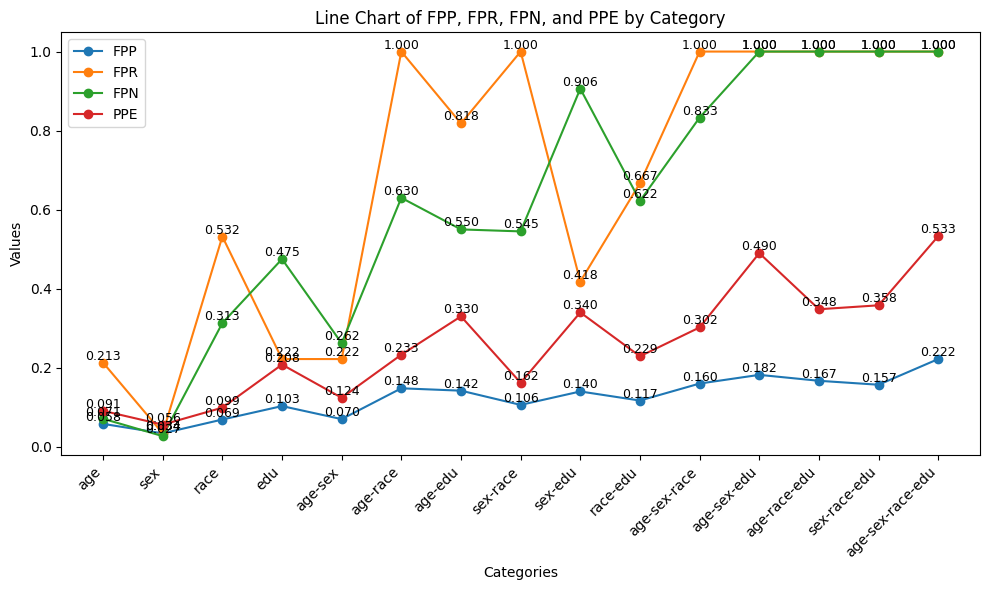

In [7]:
plot_differences(differences)

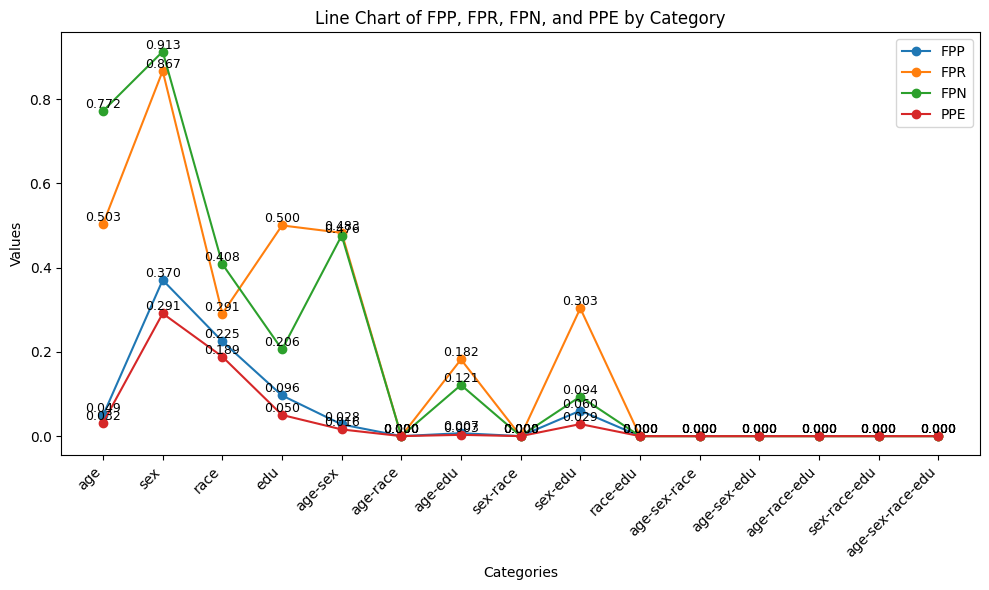

In [8]:
plot_differences(ratios)

# Plot

In [9]:
df=pd.read_csv(dataset_path)

Age:
* 11> age > 25 --> 0
* 25> age >40 --> 1
* 40> age >75 --> 2
* 75> age >90 --> 3

EDU:
* 1> edu >6 --> 0
* 6> edu >11 --> 1
* 11> edu >16 --> 2

SEX:
* female --> 0
* male --> 1

RACE:
* 'Amer-Indian-Eskimo' --> 0
* 'Asian-Pac-Islander' --> 1,
* 'Black' --> 2
* 'Other' --> 3
* 'White' --> 4



In [10]:
for m in fair_metrics:
  #print(m)
  for i in range(1, len(protected_attributes)+1):
    for sensible_attribute in pairs_dict[i]:
      s = sensible_attribute.split('-')
      #print(sensible_attribute)
      if len(s)==2:
        print_tables_penalty_2(fairness_metrics_dict, df, sensible_attribute, m, mapping, dataset_path)
      #elif len(s)==3:
        #print_tables_penalty_3(fairness_metrics_dict, df, sensible_attribute, m, mapping, dataset_path)
      #elif len(s)==4:
        #print_tables_penalty_4(fairness_metrics_dict, df, sensible_attribute, m, mapping, dataset_path)

Output hidden; open in https://colab.research.google.com to view.

In [11]:
for m in fair_metrics:
  #print(m)
  for i in range(1, len(protected_attributes)+1):
    for sensible_attribute in pairs_dict[i]:
      s = sensible_attribute.split('-')
      #print(sensible_attribute)
      #if len(s)==2:
        #print_tables_penalty_2(fairness_metrics_dict, df, sensible_attribute, m, mapping, dataset_path)
      if len(s)==3:
        print_tables_penalty_3(fairness_metrics_dict, df, sensible_attribute, m, mapping, dataset_path)
      #elif len(s)==4:
        #print_tables_penalty_4(fairness_metrics_dict, df, sensible_attribute, m, mapping, dataset_path)

Output hidden; open in https://colab.research.google.com to view.

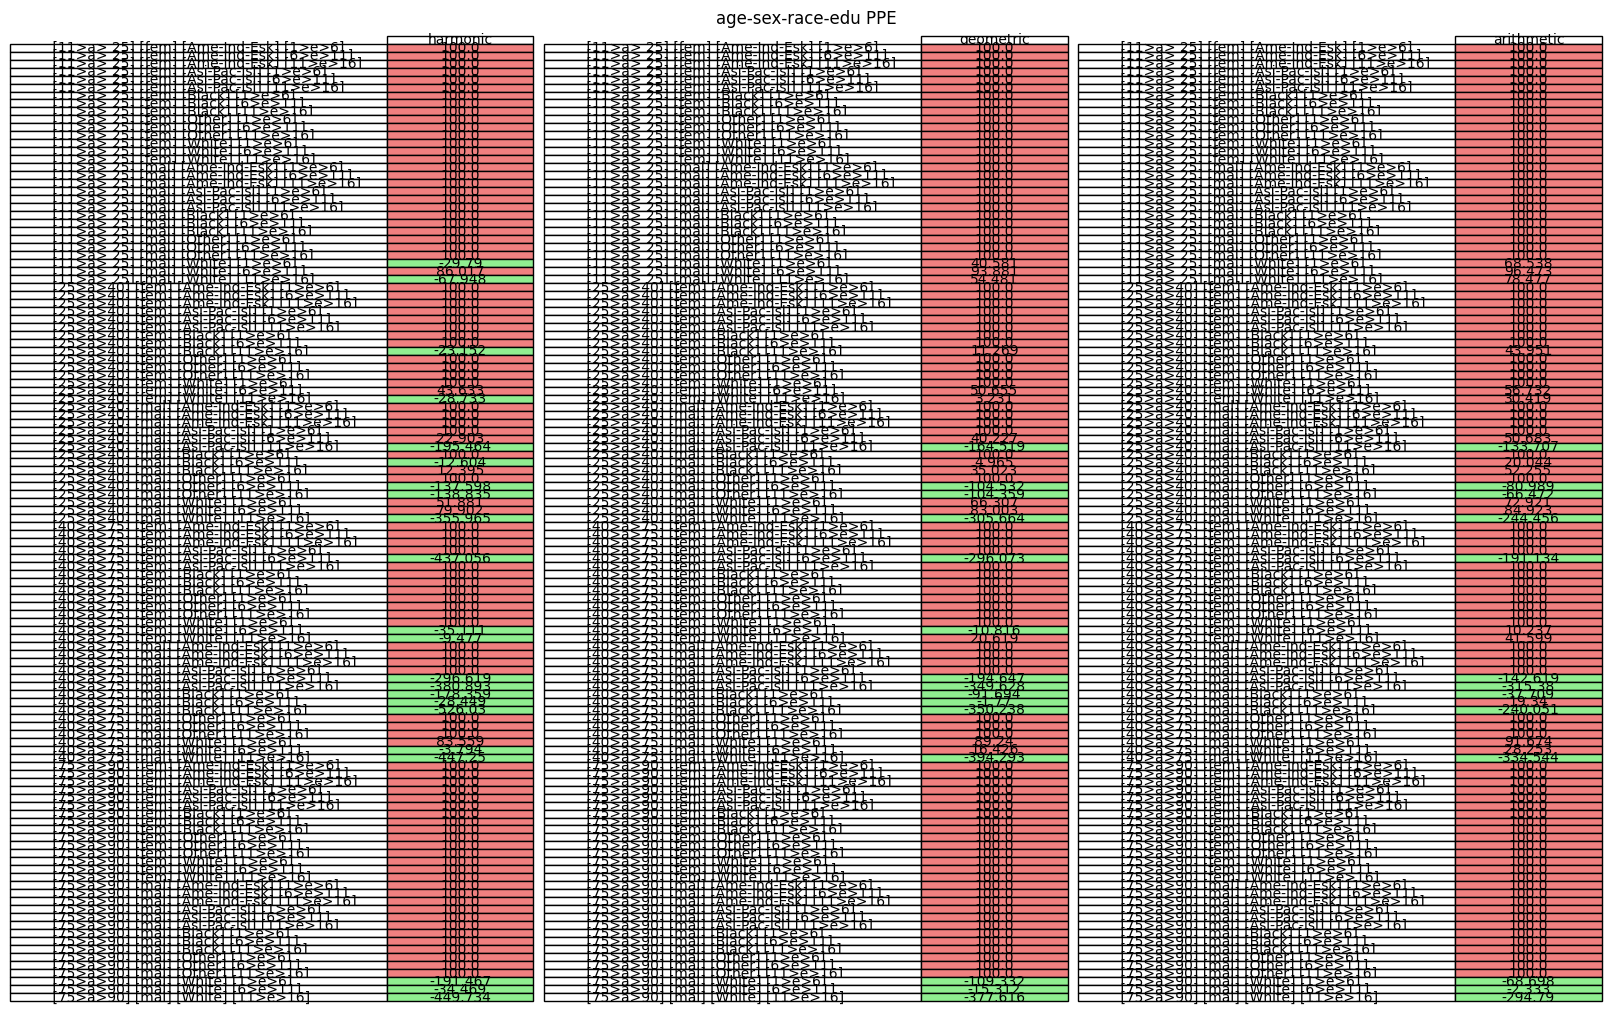

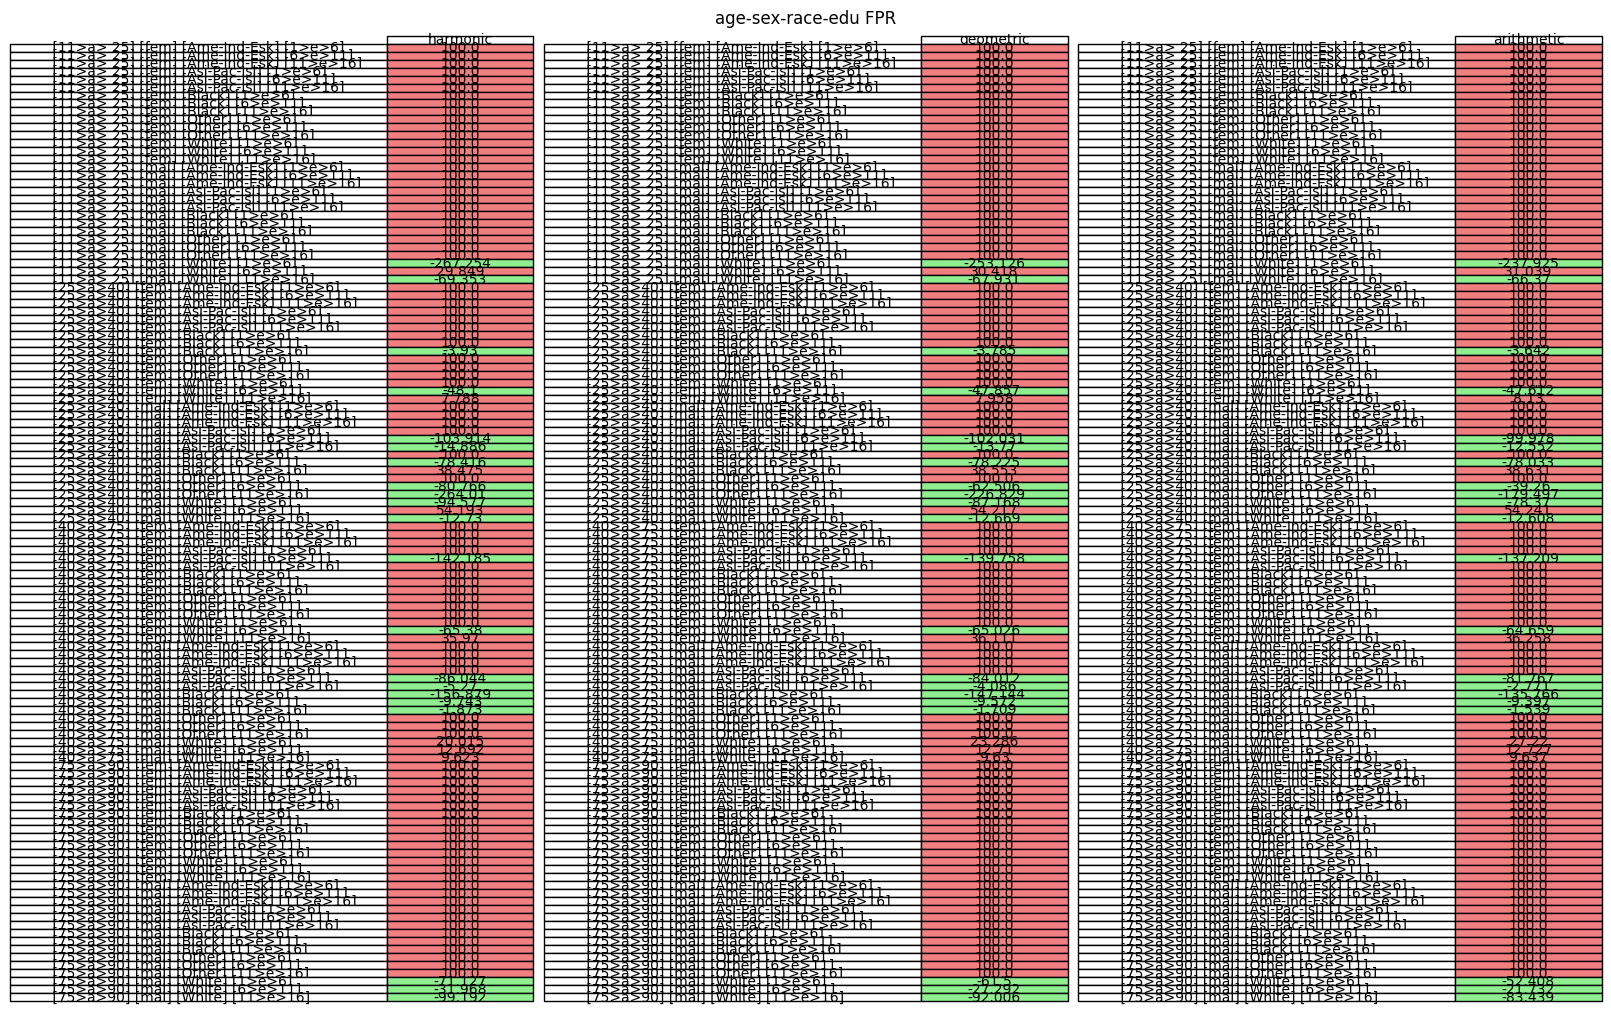

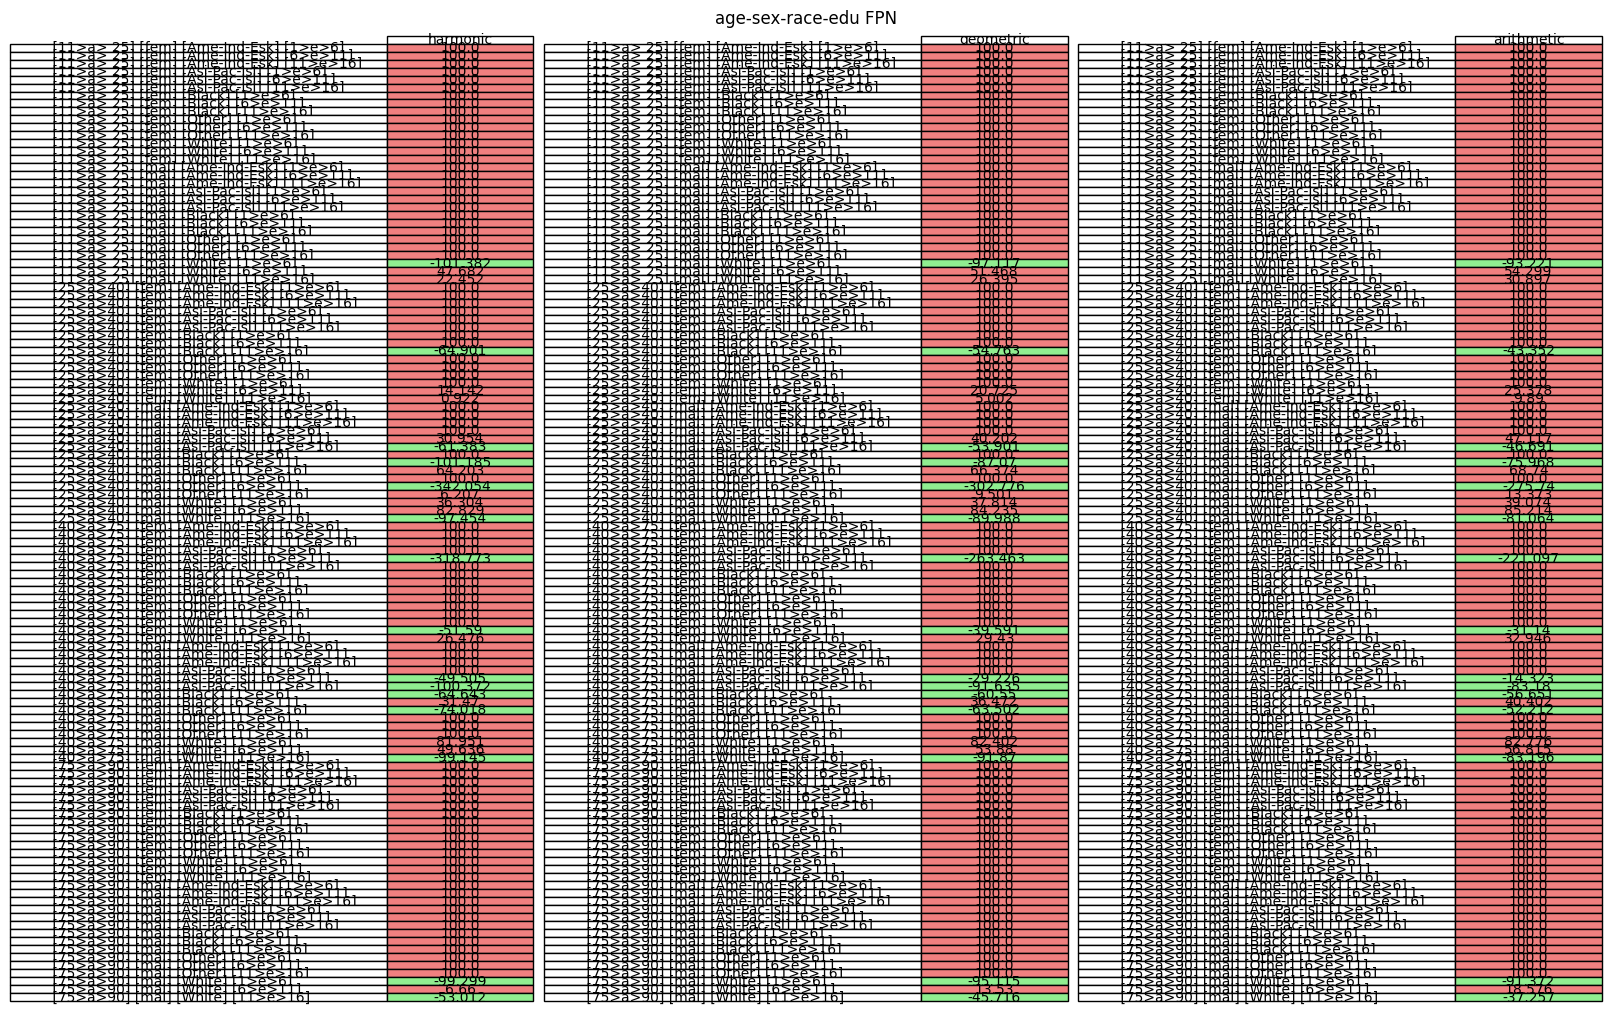

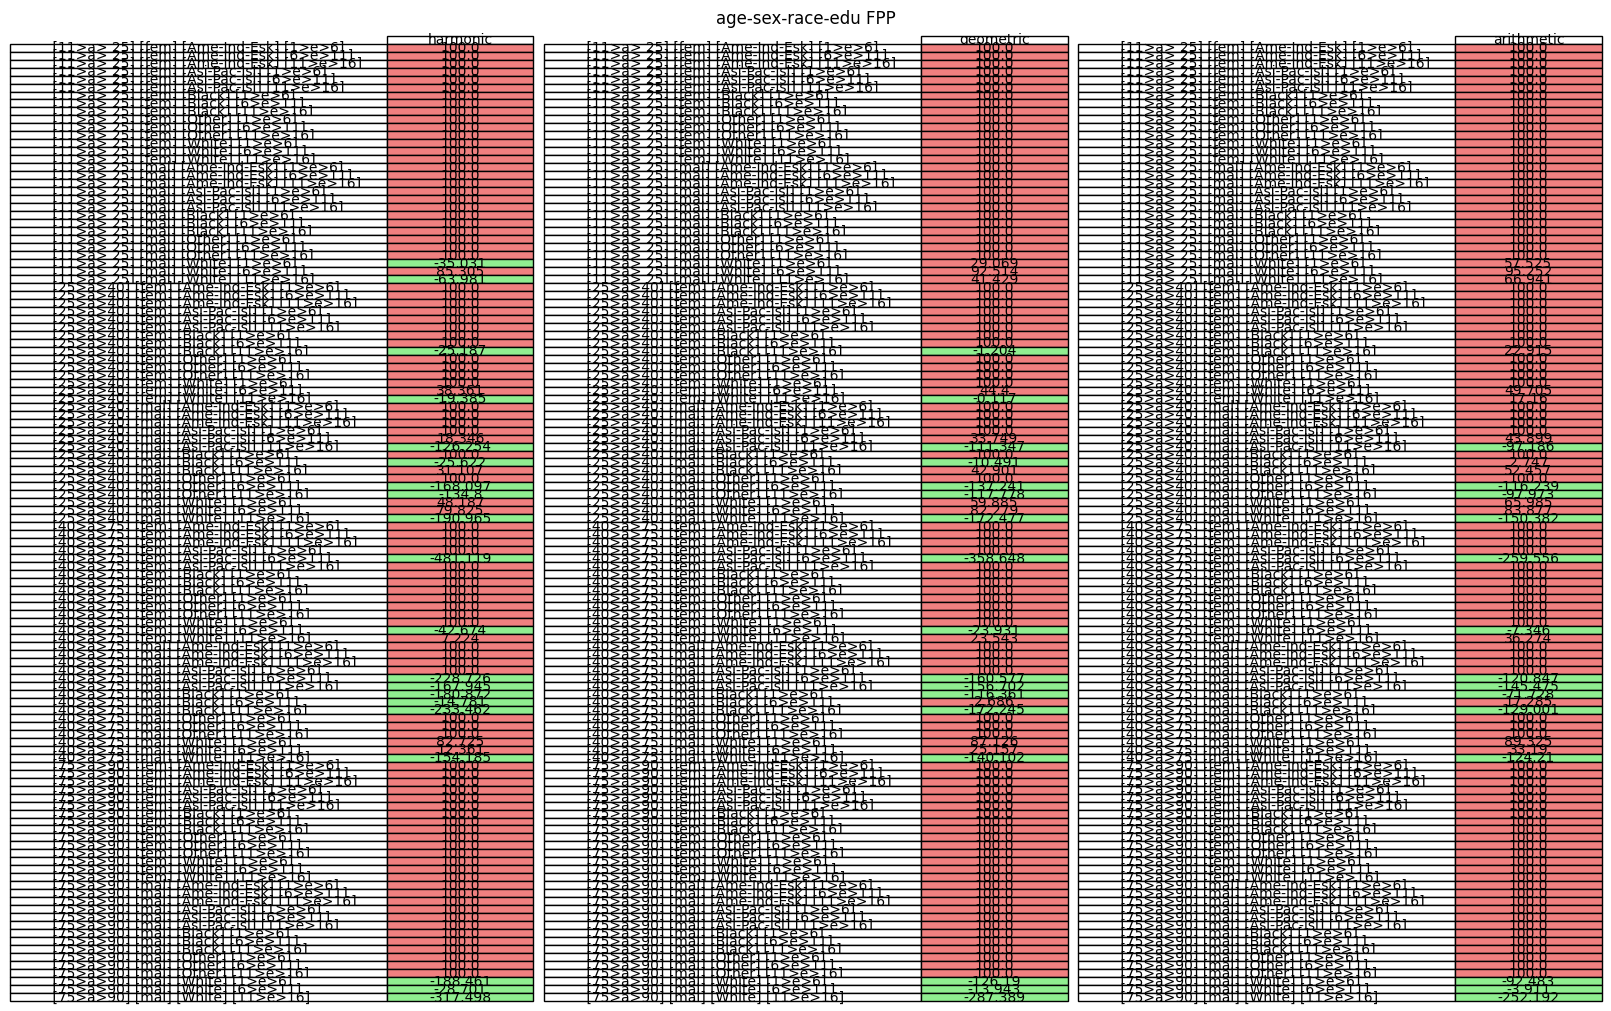

In [12]:
for m in fair_metrics:
  #print(m)
  for i in range(1, len(protected_attributes)+1):
    for sensible_attribute in pairs_dict[i]:
      s = sensible_attribute.split('-')
      #print(sensible_attribute)
      #if len(s)==2:
        #print_tables_penalty_2(fairness_metrics_dict, df, sensible_attribute, m, mapping, dataset_path)
      #elif len(s)==3:
        #print_tables_penalty_3(fairness_metrics_dict, df, sensible_attribute, m, mapping, dataset_path)
      if len(s)==4:
        print_tables_penalty_4(fairness_metrics_dict, df, sensible_attribute, m, mapping, dataset_path)

In [13]:
print('done')

done
